In [1]:
from RamanModel import *
from HelperFunctions import *
from AdaptiveKnn import *

In [2]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def knnFit_persistent_animated(samples, base_parameters, target_x, target_y, 
                              num_peaks=3, k=10, rounds=3, eps=0.15, frame_interval=5):
    """
    Modified version of knnFit_persistent that yields data frames 
    at periodic intervals to build a GIF animation.
    """
    peak_search_spaces = []
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    heap = []
    x_range = np.linspace(0, 1, len(target_y))
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)
    first_round_centers = np.empty((samples, num_peaks))
    preallocate_centers(first_round_centers, samples, num_peaks, probs, x_range)
    
    # This list will hold snapshots of data for our animation frames
    frames_data = []

    for r in range(rounds):
        current_y = np.empty_like(target_x)
        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
            centers[:, i] = np.random.uniform(p["center_range"][0], p["center_range"][1], size=samples)
            amps[:, i] = np.random.uniform(p["amplitude_range"][0], p["amplitude_range"][1], size=samples)
            gammas[:, i] = np.random.uniform(p["gamma_range"][0], p["gamma_range"][1], size=samples)

        for sample_idx in range(samples):
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                if r == 0:
                    c = first_round_centers[sample_idx, i]
                else:
                    c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            normalize_curve(current_y)
            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, sample_idx, current_params, current_y.copy()))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, sample_idx, current_params, current_y.copy()))

            # Capture a frame periodically or at the very end of a round
            if sample_idx % frame_interval == 0 or sample_idx == samples - 1:
                # Extract the current k-nearest neighbor curves stored in the heap
                neighbor_curves = [item[3] for item in heap]
                
                frames_data.append({
                    "round": r + 1,
                    "sample": sample_idx + 1,
                    "current_y": current_y.copy(),
                    "neighbors": neighbor_curves
                })
                    
        # --- Clustering Peaks & Search Space Updates ---
        nearest_neighbors = [item[2] for item in heap]
        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                all_candidate_peaks.append({"data": peak, "origin_curve": neighbor_id})

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue
            cluster_indices = [i]
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue
                dist = get_param_distance(all_candidate_peaks[i]["data"], all_candidate_peaks[j]["data"], base_parameters)
                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                for idx in cluster_indices:
                    visited[idx] = True

        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            if not cluster_indices: continue
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

    return frames_data

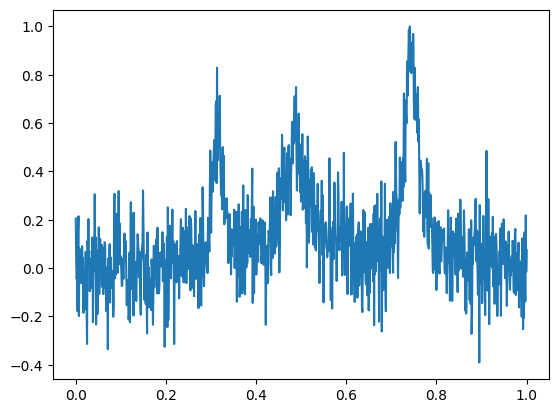

In [16]:
import matplotlib.pyplot as plt


# --- 1. Generate the "Target" Curve ---
base_parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1.0),
    "gamma_range": (0.01, 0.05),
    "x_min": 0,
    "x_max": 1
}

# Generate a target with 4 peaks and some noise
target_x, target_y, target_params = generateCurve(base_parameters, 3, 1000, 0.3)
target_y = downsample_and_normalize(target_y, resolution=1000)

# --- 2. Run the KnnFit ---
# We'll use 500 samples per round, k=10, for 3 rounds.
frames_data = knnFit_persistent_animated(
    #samples=30000,
    samples=1000,
    base_parameters=base_parameters,
    target_x=target_x,
    target_y=target_y,
    num_peaks=3,
    k=5,
    rounds=3,
    eps=0.15,
    frame_interval=10
)

plt.plot(target_x, target_y)

In [17]:
# =====================================================================
# GENERATING THE ANIMATION (WITH UPDATED COLOR PALETTE)
# =====================================================================

# 3. Initialize Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.1)
ax.set_title("KNN Persistent Peak Fitting Progression")
ax.set_xlabel("X")
ax.set_ylabel("Normalized Intensity")

# --- STYLING TRANSFORMATION ---
# 1. Target Spectrum: Soft, lower opacity light blue background reference
ax.plot(target_x, target_y, color="#33A2FF", lw=1.5, alpha=0.4, label="Target Spectrum", zorder=1)

# 2. Top-K Neighbors: Sharp, vibrant purple lines. 
# We're keeping alpha around 0.6 so they are highly visible but clean when overlapping.
neighbor_lines = [ax.plot([], [], color="#8A2BE2", lw=1.2, alpha=0.6, zorder=2)[0] for _ in range(8)]

# 3. Current Candidate: Clean red line with slightly lowered opacity to see through overlaps
current_line, = ax.plot([], [], color="#FF0000", lw=1.8, alpha=0.8, label="Current Candidate", zorder=3)
# ------------------------------

# Add a single label to the legend for neighbors to avoid duplicates
neighbor_lines[0].set_label("Top-K Neighbors")
ax.legend(loc="upper right")

text_annotation = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=10, 
                          bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# 4. Animation update function
def update(frame_idx):
    data = frames_data[frame_idx]
    
    # Update current candidate curve
    current_line.set_data(target_x, data["current_y"])
    
    # Update neighbor curves
    for line_idx, line in enumerate(neighbor_lines):
        if line_idx < len(data["neighbors"]):
            line.set_data(target_x, data["neighbors"][line_idx])
        else:
            line.set_data([], [])  # Clear if fewer than K items exist yet
            
    # Update text overlay
    text_annotation.set_text(f"Round: {data['round']} | Sample: {data['sample']}")
    return [current_line] + neighbor_lines + [text_annotation]

# 5. Compile and Save the GIF
ani = animation.FuncAnimation(fig, update, frames=len(frames_data), blit=True, interval=100)
ani.save("knn_fit_progression.gif", writer="pillow")
plt.close()

print("Animation saved successfully with new visual styles!")

Animation saved successfully with new visual styles!
